# Lab 02 — Heuristic Search on the Airline Network

**Worked Python solution.** This notebook compares UCS, Greedy Best-First Search (GBFS), and A* using Haversine distance to the destination as the heuristic.

All experiments reuse exactly the same cleaned graph and edge-cost function as Lab 01.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

from search_toolkit import load_openflights, ucs, gbfs, astar, haversine_km
from heapq import heappush, heappop

RESULTS = ROOT / "results" / "lab02"
RESULTS.mkdir(parents=True, exist_ok=True)
_, _, coords, adjacency, stats = load_openflights(
    ROOT/"all_datasets"/"lab01-03_airports.csv",
    ROOT/"all_datasets"/"lab01-03_routes.csv")
queries = pd.read_csv(ROOT/"config"/"search_queries.csv").head(3)

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


## 1. UCS baseline, GBFS, and A*

In [2]:
rows=[]
for q in queries.itertuples(index=False):
    h = lambda n, goal=q.goal: haversine_km(
        coords[n]["latitude"], coords[n]["longitude"],
        coords[goal]["latitude"], coords[goal]["longitude"])
    methods = {
        "UCS": lambda: ucs(adjacency,q.start,q.goal),
        "GBFS": lambda: gbfs(adjacency,q.start,q.goal,h),
        "A*": lambda: astar(adjacency,q.start,q.goal,h),
        "A* (1.5h)": lambda: astar(adjacency,q.start,q.goal,lambda n:1.5*h(n)),
    }
    for name, fn in methods.items():
        r=fn()
        rows.append({"query_id":q.query_id,"start":q.start,"goal":q.goal,
                     "algorithm":name,"cost_km":r.path_cost_km,"hops":r.hops,
                     "expanded":r.expanded,"max_frontier":r.max_frontier,
                     "runtime_ms":r.runtime_ms,"path":" -> ".join(r.path)})
metrics=pd.DataFrame(rows)
metrics.to_csv(RESULTS/"metrics.csv",index=False)
metrics[["query_id","algorithm","cost_km","hops","expanded","runtime_ms"]].round(2)

,query_id,algorithm,cost_km,hops,expanded,runtime_ms
0,Q1,UCS,11461.35,4,1852,5.47
1,Q1,GBFS,12500.50,2,3,0.39
2,Q1,A*,11461.35,4,70,0.76
3,Q1,A* (1.5h),12274.32,2,3,0.46
4,Q2,UCS,17817.36,3,3003,8.75
5,Q2,GBFS,17817.36,3,4,0.39
6,Q2,A*,17817.36,3,152,0.94
7,Q2,A* (1.5h),17817.36,3,4,0.81
8,Q3,UCS,14813.32,3,3043,9.02
9,Q3,GBFS,15811.29,3,4,0.35


**Answer.** With the ordinary Haversine heuristic, A* should match UCS cost because straight-line distance cannot exceed the sum of straight-line legs along any route. GBFS uses only the heuristic, so it usually expands very few nodes but may return a more expensive path. The deliberately inflated `1.5h` heuristic demonstrates the trade-off: fewer expansions can come at the cost of the optimality guarantee.

## 2. Empirical admissibility check

We compute exact cost-to-go values by running Dijkstra once from each goal on the reversed graph, then compare them with the Haversine heuristic for 10 reachable airports.

In [3]:
def reverse_graph(adj):
    rev={u:[] for u in adj}
    for u,edges in adj.items():
        for v,c in edges:
            rev.setdefault(v,[]).append((u,c))
    return rev


def dijkstra_all(adj,start):
    dist={start:0.0}; heap=[(0.0,start)]
    while heap:
        d,u=heappop(heap)
        if d!=dist.get(u): continue
        for v,c in adj.get(u,[]):
            nd=d+c
            if nd < dist.get(v,float("inf")):
                dist[v]=nd; heappush(heap,(nd,v))
    return dist

rev=reverse_graph(adjacency)
checks=[]
for q in queries.itertuples(index=False):
    exact_to_goal=dijkstra_all(rev,q.goal)
    candidates=sorted(exact_to_goal, key=lambda n: exact_to_goal[n])
    # evenly sample reachable states while avoiding the goal itself
    sample=[candidates[i] for i in np.linspace(1,len(candidates)-1,10,dtype=int)]
    for n in sample:
        h=haversine_km(coords[n]["latitude"],coords[n]["longitude"],
                       coords[q.goal]["latitude"],coords[q.goal]["longitude"])
        exact=exact_to_goal[n]
        checks.append({"query_id":q.query_id,"airport":n,"goal":q.goal,
                       "haversine_km":h,"shortest_route_km":exact,
                       "admissible":h <= exact + 1e-8})
heuristic_check=pd.DataFrame(checks)
heuristic_check.to_csv(RESULTS/"heuristic_check.csv",index=False)
print("Admissibility violations:", (~heuristic_check.admissible).sum())
heuristic_check.head(12).round(2)

Admissibility violations: 0


,query_id,airport,goal,haversine_km,shortest_route_km,admissible
0,Q1,GLA,KEF,1347.46,1347.46,True
1,Q1,IBZ,KEF,3206.35,3244.50,True
2,Q1,GZP,KEF,4744.91,4745.74,True
3,Q1,TUU,KEF,5710.90,5847.10,True
4,Q1,OAK,KEF,6731.27,6893.04,True
5,Q1,ANC,KEF,5424.45,8136.99,True
6,Q1,JSR,KEF,8696.84,9238.72,True
7,Q1,AKY,KEF,9162.99,10503.70,True
8,Q1,ZCO,KEF,12238.32,12935.76,True
9,Q1,OTD,KEF,7561.17,30818.53,True


## 3. Search-effort comparison

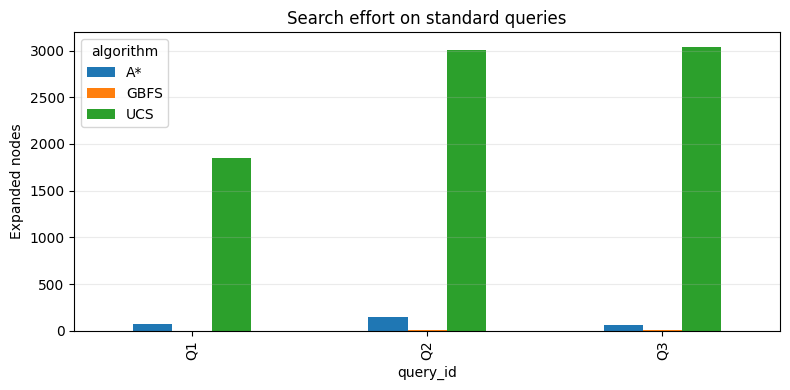

A* matches UCS on all tested costs: True
Mean A* expansion reduction vs UCS: 96.4%
GBFS returns a higher-cost route on 2 of 3 queries


In [4]:
plot_df=metrics[metrics.algorithm.isin(["UCS","GBFS","A*"])].pivot(index="query_id",columns="algorithm",values="expanded")
ax=plot_df.plot(kind="bar",figsize=(8,4))
ax.set_ylabel("Expanded nodes"); ax.set_title("Search effort on standard queries")
ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.savefig(RESULTS/"expanded_nodes.png",dpi=160); plt.show()

base=metrics[metrics.algorithm=="UCS"].set_index("query_id")
astar_df=metrics[metrics.algorithm=="A*"].set_index("query_id")
gbfs_df=metrics[metrics.algorithm=="GBFS"].set_index("query_id")
print("A* matches UCS on all tested costs:", np.allclose(base.cost_km,astar_df.cost_km))
print("Mean A* expansion reduction vs UCS: {:.1%}".format(1-astar_df.expanded.mean()/base.expanded.mean()))
print("GBFS returns a higher-cost route on", int((gbfs_df.cost_km>base.cost_km+1e-6).sum()), "of",len(base),"queries")

## Worked interpretation

The Haversine heuristic is both **informative and admissible** for this cost definition. In the supplied data, A* preserves the UCS route cost while expanding dramatically fewer airports. GBFS is faster in node expansions but is not cost-optimal. Inflating the heuristic makes A* behave more greedily; this can be useful in time-constrained applications, but the resulting route should no longer be described as guaranteed optimal.